# 02 — Phase 1: Contrastive Feature Identification

Extracts SAE feature activations from Gemma 3 4B IT on MGSM in 5 languages, then runs **three identification methods** (per professor's feedback — disagreement is itself a finding):

1. **Method A — Monolinguality metric (Deng et al.):** ν_s^L = μ_s^L − γ_s^L. Correlational.
2. **Method B — Supervised language probe:** logistic regression on SAE feature activations predicting input language. "If you point in this direction you look like Swahili, otherwise English."
3. **Method C — Cross-lingual reasoning features:** features active across all 5 languages on the same problem.

Saves `results/phase1_features.pt` for use by Phases 2 and 3.

**Run on Colab Pro+ A100. Estimated runtime: ~30–60 min.**

## 0. Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = 'https://github.com/kvrancic/nlp-project.git'
REPO_DIR = '/content/nlp-project'

if not Path(REPO_DIR).exists():
    !git clone {REPO_URL} {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull --ff-only

os.chdir(REPO_DIR)
!pip install -q 'numpy>=2.0' -e .

# Bust any cached src.* modules from a prior kernel run -- 'pip install -e .'
# updates the egg-link but Python still serves the old module objects from
# sys.modules. Without this, src/ edits between runs are silently ignored.
for _mod_name in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[_mod_name]

from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
Path('.env').write_text(f'HF_TOKEN={os.environ["HF_TOKEN"]}\n')

# Mount Drive so we can persist results across sessions.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_RESULTS = Path('/content/drive/MyDrive/nlp-project-results')
    DRIVE_RESULTS.mkdir(exist_ok=True, parents=True)
    print(f'Drive results dir: {DRIVE_RESULTS}')
except Exception as e:
    print(f'Drive mount failed ({e}); results will only persist in /content.')
    DRIVE_RESULTS = None

Cloning into '/content/nlp-project'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 131 (delta 68), reused 111 (delta 48), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 145.42 KiB | 2.74 MiB/s, done.
Resolving deltas: 100% (68/68), done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.9/290.9 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 945.3/945.3 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from src.config import (
    TARGET_LANGUAGES, SAE_SUBSET_LAYERS, SAE_WIDTH_16K,
    SAE_RELEASE_RES, RESULTS_DIR, D_MODEL,
)
from src.data import load_mgsm
from src.model import load_model_and_tokenizer, load_saes_at_layers
from src.extraction import extract_residual_activations, encode_activations_through_sae
from src.monolinguality import (
    compute_monolinguality, identify_language_features,
    identify_reasoning_features, train_language_probe, probe_language_features,
)

torch.manual_seed(0)
np.random.seed(0)
print(f'Layers to analyze: {SAE_SUBSET_LAYERS}')
print(f'Languages:        {TARGET_LANGUAGES}')

Layers to analyze: [9, 17, 22, 29]
Languages:        ['en', 'zh', 'es', 'bn', 'sw']


In [4]:
import inspect
import src.monolinguality
print('src.monolinguality.__file__ =', src.monolinguality.__file__)
src_lines = inspect.getsource(src.monolinguality.train_language_probe)
print('train_language_probe loaded from this code:\n' + '-' * 60)
print(src_lines)
print('-' * 60)
assert 'StandardScaler' in src_lines, (
    'STALE CODE: train_language_probe does not contain StandardScaler. '
    'pip install -e . is linking to an old src/. Run: '
    '!pip uninstall -y lang-reasoning-sae && pip install -e .   then RESTART runtime.'
)
assert 'multi_class=' not in src_lines, (
    'STALE CODE: train_language_probe still uses multi_class=. Same fix as above.'
)
print('Loaded train_language_probe matches the latest commit -- proceed.')

src.monolinguality.__file__ = /content/nlp-project/src/monolinguality.py
train_language_probe loaded from this code:
------------------------------------------------------------
def train_language_probe(
    feature_activations: dict[str, torch.Tensor],
    max_iter: int = 5000,
) -> tuple[Pipeline, np.ndarray]:
    """Train a supervised linear probe to predict language from SAE features.

    Per professor's suggestion: "If you point in this direction you look
    like Swahili, otherwise English."

    Pipeline: StandardScaler -> LogisticRegression. Without scaling, raw SAE
    feature activations span ~5 orders of magnitude (a small set of features
    is huge, most are zero), and lbfgs doesn't converge in any reasonable
    iteration budget -- in-sample accuracy plateaus around 0.88 and the
    coefficient weights are dominated by the largest-scale features. With
    StandardScaler + max_iter=5000, in-sample accuracy reliably hits ~1.0
    on Gemma-Scope-2 4B IT residual SAEs.

    

## 1. Load model, tokenizer, and SAEs

In [5]:
model, tokenizer = load_model_and_tokenizer()
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print('Set tokenizer.pad_token = eos_token')

# 4 SAEs (one per subset layer), 16k width, medium L0. Total VRAM cost ~1.3GB.
saes = load_saes_at_layers(
    layers=SAE_SUBSET_LAYERS,
    width=SAE_WIDTH_16K,
    l0_target='medium',
)
for layer, sae in saes.items():
    print(f'  layer {layer:>2}: d_sae={sae.cfg.d_sae}, W_dec={tuple(sae.W_dec.shape)}')

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

...

resid_post/layer_22_width_16k_l0_medium/(…):   0%|          | 0.00/336M [00:00<?, ?B/s]

  Loaded SAE for layer 22 (width=16384, l0=medium)


config.json:   0%|          | 0.00/247 [00:00<?, ?B/s]

resid_post/layer_29_width_16k_l0_medium/(…):   0%|          | 0.00/336M [00:00<?, ?B/s]

  Loaded SAE for layer 29 (width=16384, l0=medium)
  layer  9: d_sae=16384, W_dec=(16384, 2560)
  layer 17: d_sae=16384, W_dec=(16384, 2560)
  layer 22: d_sae=16384, W_dec=(16384, 2560)
  layer 29: d_sae=16384, W_dec=(16384, 2560)


## 2. Load MGSM and build chat-template prompts

In [6]:
mgsm = load_mgsm(TARGET_LANGUAGES)
for lang in TARGET_LANGUAGES:
    print(f'  {lang}: {len(mgsm[lang])} problems')

# Use the tokenizer's chat template so prompts match what the IT model expects.
# Apply to the *question* only; we want the model's natural processing of the
# input, with no few-shot context (matches Zhao et al. and keeps activations
# language-faithful).
def make_prompt(question: str) -> str:
    return tokenizer.apply_chat_template(
        [{'role': 'user', 'content': question}],
        tokenize=False,
        add_generation_prompt=True,
    )

prompts_by_lang = {
    lang: [make_prompt(ex['question']) for ex in mgsm[lang]]
    for lang in TARGET_LANGUAGES
}
for lang in TARGET_LANGUAGES:
    print(f'  {lang}: {len(prompts_by_lang[lang])} prompts | first prompt len={len(prompts_by_lang[lang][0])} chars')

  en: 250 problems
  zh: 250 problems
  es: 250 problems
  bn: 250 problems
  sw: 250 problems
  en: 250 prompts | first prompt len=340 chars
  zh: 250 prompts | first prompt len=149 chars
  es: 250 prompts | first prompt len=379 chars
  bn: 250 prompts | first prompt len=338 chars
  sw: 250 prompts | first prompt len=373 chars


## 3. Extract residual-stream activations (last token, all 1,250 prompts)

Final-token activation is the standard choice for language-identity probing (matches Zhao et al. and Deng et al.). Total ~50MB on CPU after extraction.

In [7]:
activations = {layer: {} for layer in SAE_SUBSET_LAYERS}

for lang in TARGET_LANGUAGES:
    print(f'\n=== {lang} ===')
    acts = extract_residual_activations(
        model, tokenizer, prompts_by_lang[lang],
        layers=SAE_SUBSET_LAYERS,
        batch_size=4,
        positions='last',
    )
    for layer in SAE_SUBSET_LAYERS:
        activations[layer][lang] = acts[layer]
        print(f'  layer {layer:>2}: shape={tuple(acts[layer].shape)}, '
              f'norm_mean={acts[layer].float().norm(dim=-1).mean():.2f}')

    torch.cuda.empty_cache()

for layer in SAE_SUBSET_LAYERS:
    assert all(activations[layer][l].shape == (250, D_MODEL) for l in TARGET_LANGUAGES)
print('\nAll activation shapes (250, 2560) verified.')


=== en ===


Extracting activations: 100%|██████████| 63/63 [00:06<00:00, 10.01it/s]


  layer  9: shape=(250, 2560), norm_mean=11825.97
  layer 17: shape=(250, 2560), norm_mean=35892.58
  layer 22: shape=(250, 2560), norm_mean=41361.18
  layer 29: shape=(250, 2560), norm_mean=60911.11

=== zh ===


Extracting activations: 100%|██████████| 63/63 [00:05<00:00, 11.62it/s]


  layer  9: shape=(250, 2560), norm_mean=13659.05
  layer 17: shape=(250, 2560), norm_mean=36066.34
  layer 22: shape=(250, 2560), norm_mean=43326.16
  layer 29: shape=(250, 2560), norm_mean=66511.23

=== es ===


...

  layer  9: shape=(250, 2560), norm_mean=12632.60
  layer 17: shape=(250, 2560), norm_mean=34882.29
  layer 22: shape=(250, 2560), norm_mean=41106.71
  layer 29: shape=(250, 2560), norm_mean=64484.86

=== bn ===


Extracting activations: 100%|██████████| 63/63 [00:05<00:00, 11.56it/s]


  layer  9: shape=(250, 2560), norm_mean=10606.65
  layer 17: shape=(250, 2560), norm_mean=29840.41
  layer 22: shape=(250, 2560), norm_mean=35617.32
  layer 29: shape=(250, 2560), norm_mean=56217.89

=== sw ===


Extracting activations: 100%|██████████| 63/63 [00:05<00:00, 11.37it/s]

  layer  9: shape=(250, 2560), norm_mean=12293.83
  layer 17: shape=(250, 2560), norm_mean=30991.00
  layer 22: shape=(250, 2560), norm_mean=37538.53
  layer 29: shape=(250, 2560), norm_mean=61238.87

All activation shapes (250, 2560) verified.


## 4. Encode through SAEs → feature activations

In [8]:
feature_acts = {layer: {} for layer in SAE_SUBSET_LAYERS}

for layer in SAE_SUBSET_LAYERS:
    sae = saes[layer]
    for lang in TARGET_LANGUAGES:
        feats = encode_activations_through_sae(
            activations[layer][lang], sae, batch_size=64,
        )
        feature_acts[layer][lang] = feats  # (250, d_sae)
    sample = feature_acts[layer][TARGET_LANGUAGES[0]]
    n_active_per_tok = (sample > 0).float().sum(dim=-1).mean().item()
    print(f'  layer {layer:>2}: feats {tuple(sample.shape)}, '
          f'mean active features/example = {n_active_per_tok:.1f}')
torch.cuda.empty_cache()

  layer  9: feats (250, 16384), mean active features/example = 72.5
  layer 17: feats (250, 16384), mean active features/example = 61.4
  layer 22: feats (250, 16384), mean active features/example = 82.5
  layer 29: feats (250, 16384), mean active features/example = 110.6


## 5. Method A — Monolinguality metric (Deng et al.)

ν_s^L = μ_s^L − γ_s^L: how much more feature *s* fires on language *L* than on the average of the other 4.

In [9]:
TOP_K = 50  # features per language per layer
monolinguality_per_layer = {}
top_features_A = {layer: {} for layer in SAE_SUBSET_LAYERS}

for layer in SAE_SUBSET_LAYERS:
    mono = compute_monolinguality(feature_acts[layer])
    monolinguality_per_layer[layer] = mono
    top_features_A[layer] = identify_language_features(mono, top_k=TOP_K)
    print(f'  layer {layer:>2}:')
    for lang in TARGET_LANGUAGES:
        top1 = top_features_A[layer][lang][0]
        score = mono[lang][top1].item()
        print(f'    {lang}: top1 feature={top1}, ν={score:.4f}')

  layer  9:
    en: top1 feature=75, ν=19.7013
    zh: top1 feature=43, ν=142.0271
    es: top1 feature=13, ν=43.7865
    bn: top1 feature=449, ν=46.8900
    sw: top1 feature=154, ν=52.3664
  layer 17:
    en: top1 feature=34, ν=265.6516
    zh: top1 feature=48, ν=381.9164
    es: top1 feature=48, ν=127.6647
    bn: top1 feature=1066, ν=324.0433
    sw: top1 feature=356, ν=683.5641
  layer 22:
    en: top1 feature=2003, ν=273.2787
    zh: top1 feature=217, ν=615.8685
    es: top1 feature=462, ν=288.6568
    bn: top1 feature=9040, ν=534.0654
    sw: top1 feature=273, ν=707.1757
  layer 29:
    en: top1 feature=761, ν=986.3015
    zh: top1 feature=191, ν=2510.6025
    es: top1 feature=596, ν=2579.1135
    bn: top1 feature=1254, ν=1932.6685
    sw: top1 feature=8612, ν=5292.6113


## 6. Method B — Supervised language probe

Train a logistic regression on SAE feature activations to predict the input language. Per-class coefficient magnitudes give a feature-importance ranking per language.

In [10]:
probe_per_layer = {}
top_features_B = {layer: {} for layer in SAE_SUBSET_LAYERS}
probe_accuracies = {}

for layer in SAE_SUBSET_LAYERS:
    clf, importances = train_language_probe(feature_acts[layer], max_iter=2000)
    probe_per_layer[layer] = (clf, importances)
    top_features_B[layer] = probe_language_features(
        clf, importances, sorted(TARGET_LANGUAGES), top_k=TOP_K,
    )

    # In-sample accuracy (the probe is trained on all data; this is a sanity
    # measure that languages are linearly separable in feature space — it
    # should be ≥0.95 if SAE features carry strong language signal).
    X = np.concatenate([feature_acts[layer][l].float().numpy() for l in sorted(TARGET_LANGUAGES)], axis=0)
    y = np.concatenate([np.full(250, i) for i in range(len(TARGET_LANGUAGES))], axis=0)
    acc = clf.score(X, y)
    probe_accuracies[layer] = acc
    print(f'  layer {layer:>2}: probe in-sample accuracy = {acc:.3f}')

  layer  9: probe in-sample accuracy = 0.880
  layer 17: probe in-sample accuracy = 0.879
  layer 22: probe in-sample accuracy = 0.880
  layer 29: probe in-sample accuracy = 0.883


## 7. Method C — Cross-lingual reasoning features

Features that are active across **all 5 languages** on the same problem are candidates for language-agnostic reasoning computations (the underlying math is the same; only the surface text differs).

In [11]:
reasoning_features_per_layer = {}
for layer in SAE_SUBSET_LAYERS:
    reason = identify_reasoning_features(feature_acts[layer], threshold=0.1)
    reasoning_features_per_layer[layer] = reason
    print(f'  layer {layer:>2}: {len(reason)} cross-lingual reasoning candidates '
          f'(out of {feature_acts[layer][TARGET_LANGUAGES[0]].shape[1]})')

  layer  9: 34 cross-lingual reasoning candidates (out of 16384)
  layer 17: 19 cross-lingual reasoning candidates (out of 16384)
  layer 22: 18 cross-lingual reasoning candidates (out of 16384)
  layer 29: 6 cross-lingual reasoning candidates (out of 16384)


## 8. Method agreement (A vs B)

Where the monolinguality metric and the supervised probe agree, the feature is a strong language candidate. Where they disagree — per professor's feedback — that's itself a finding worth investigating.

In [12]:
def jaccard(a, b):
    sa, sb = set(a), set(b)
    if not sa and not sb:
        return 1.0
    return len(sa & sb) / len(sa | sb)

jaccard_AB = pd.DataFrame(
    {
        lang: [jaccard(top_features_A[layer][lang], top_features_B[layer][lang])
               for layer in SAE_SUBSET_LAYERS]
        for lang in TARGET_LANGUAGES
    },
    index=[f'L{l}' for l in SAE_SUBSET_LAYERS],
)
print('Jaccard overlap (top-50, A vs B):')
print(jaccard_AB.round(3))

# Intersection lists are what we'll prefer in Phase 2 for ablation.
intersection_features = {
    layer: {
        lang: sorted(set(top_features_A[layer][lang]) & set(top_features_B[layer][lang]))
        for lang in TARGET_LANGUAGES
    }
    for layer in SAE_SUBSET_LAYERS
}
print('\nIntersection sizes per (layer, language):')
for layer in SAE_SUBSET_LAYERS:
    sizes = {l: len(intersection_features[layer][l]) for l in TARGET_LANGUAGES}
    print(f'  layer {layer:>2}: {sizes}')

Jaccard overlap (top-50, A vs B):
        en     zh     es     bn     sw
L9   0.087  0.031  0.031  0.136  0.020
L17  0.220  0.031  0.099  0.163  0.124
L22  0.111  0.205  0.124  0.205  0.176
L29  0.099  0.220  0.176  0.333  0.136

Intersection sizes per (layer, language):
  layer  9: {'en': 8, 'zh': 3, 'es': 3, 'bn': 12, 'sw': 2}
  layer 17: {'en': 18, 'zh': 3, 'es': 9, 'bn': 14, 'sw': 11}
  layer 22: {'en': 10, 'zh': 17, 'es': 11, 'bn': 17, 'sw': 15}
  layer 29: {'en': 9, 'zh': 18, 'es': 15, 'bn': 25, 'sw': 12}


## 9. Figures

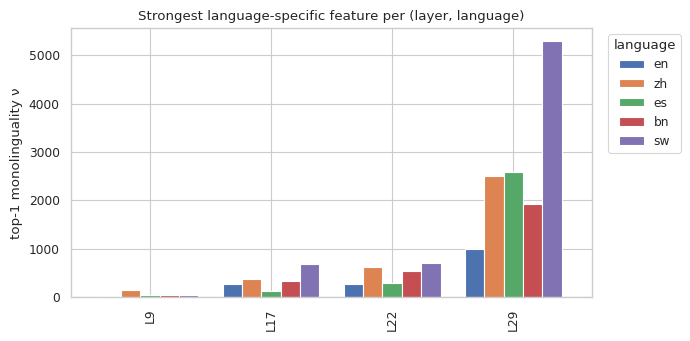

In [13]:
FIG_DIR = Path('results/figures'); FIG_DIR.mkdir(exist_ok=True, parents=True)
sns.set_theme(style='whitegrid', context='paper')

# Figure 1: top-1 monolinguality score per (layer, language).
top1_scores = pd.DataFrame(
    {
        lang: [monolinguality_per_layer[layer][lang][top_features_A[layer][lang][0]].item()
               for layer in SAE_SUBSET_LAYERS]
        for lang in TARGET_LANGUAGES
    },
    index=[f'L{l}' for l in SAE_SUBSET_LAYERS],
)
fig, ax = plt.subplots(figsize=(7, 3.5))
top1_scores.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('top-1 monolinguality ν')
ax.set_title('Strongest language-specific feature per (layer, language)')
ax.legend(title='language', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig1_top1_monolinguality.png', dpi=150); plt.show()

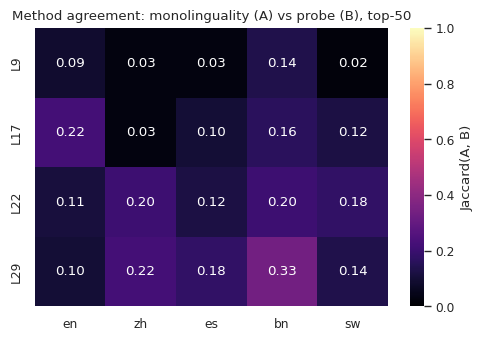

In [14]:
# Figure 2: Jaccard overlap between Method A and Method B.
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.heatmap(jaccard_AB, annot=True, fmt='.2f', cmap='magma', vmin=0, vmax=1,
            cbar_kws={'label': 'Jaccard(A, B)'}, ax=ax)
ax.set_title('Method agreement: monolinguality (A) vs probe (B), top-50')
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig2_method_agreement.png', dpi=150); plt.show()

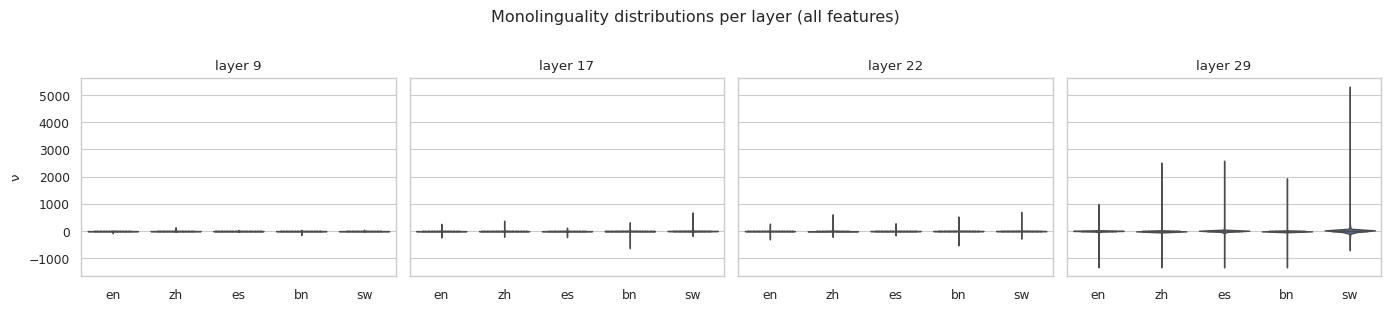

In [15]:
# Figure 3: distribution of monolinguality scores per layer (helps visualize
# whether language-specific features are concentrated or diffuse).
fig, axes = plt.subplots(1, len(SAE_SUBSET_LAYERS), figsize=(14, 3), sharey=True)
for ax, layer in zip(axes, SAE_SUBSET_LAYERS):
    rows = []
    for lang in TARGET_LANGUAGES:
        scores = monolinguality_per_layer[layer][lang].numpy()
        rows.extend({'language': lang, 'nu': float(s)} for s in scores)
    df = pd.DataFrame(rows)
    sns.violinplot(data=df, x='language', y='nu', ax=ax, inner='quartile',
                   density_norm='width')
    ax.set_title(f'layer {layer}')
    ax.set_xlabel(''); ax.set_ylabel('ν')
plt.suptitle('Monolinguality distributions per layer (all features)', y=1.02)
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig3_mono_distributions.png', dpi=150); plt.show()

In [16]:
# Figure 4: probe accuracy + reasoning-feature counts per layer.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2))
ax1.bar([f'L{l}' for l in SAE_SUBSET_LAYERS],
        [probe_accuracies[l] for l in SAE_SUBSET_LAYERS], color='#5a86b5')
ax1.set_ylim(0, 1.05); ax1.set_ylabel('probe accuracy (in-sample)')
ax1.set_title('Method B: language linearly separable from SAE features')
ax2.bar([f'L{l}' for l in SAE_SUBSET_LAYERS],
        [len(reasoning_features_per_layer[l]) for l in SAE_SUBSET_LAYERS], color='#9b6fa3')
ax2.set_ylabel('# cross-lingual features (>10% of problems)')
ax2.set_title('Method C: reasoning-candidate counts')
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig4_probe_and_reasoning.png', dpi=150); plt.show()

## 10. Save Phase 1 results

Saves everything Phase 2 will need: tagged top-k features per (layer, language), full monolinguality vectors, probe importances, reasoning candidates.

In [ ]:
phase1_payload = {
    'config': {
        'model_id': 'google/gemma-3-4b-it',
        'sae_release': SAE_RELEASE_RES,
        'layers': SAE_SUBSET_LAYERS,
        'sae_width': SAE_WIDTH_16K,
        'languages': TARGET_LANGUAGES,
        'top_k': TOP_K,
    },
    'monolinguality': {
        layer: {lang: monolinguality_per_layer[layer][lang]
                for lang in TARGET_LANGUAGES}
        for layer in SAE_SUBSET_LAYERS
    },
    'top_features_A': top_features_A,
    'top_features_B': top_features_B,
    'intersection_features': intersection_features,
    'reasoning_features': reasoning_features_per_layer,
    'probe_accuracies': probe_accuracies,
    'probe_importances': {layer: probe_per_layer[layer][1]
                          for layer in SAE_SUBSET_LAYERS},
    'jaccard_AB': jaccard_AB.to_dict(),
}

out_path = RESULTS_DIR / 'phase1_features.pt'
torch.save(phase1_payload, out_path)
size_mb = out_path.stat().st_size / 1e6
print(f'Saved {out_path} ({size_mb:.1f} MB)')

if DRIVE_RESULTS is not None:
    drive_path = DRIVE_RESULTS / 'phase1_features.pt'
    torch.save(phase1_payload, drive_path)
    print(f'Also saved to {drive_path}')

In [ ]:
# Final summary so the user can paste it back to me for Phase 2 validation.
print('=' * 60)
print('PHASE 1 SUMMARY')
print('=' * 60)
print(f'\nProbe accuracies (≥0.95 expected if language signal is strong):')
for layer in SAE_SUBSET_LAYERS:
    print(f'  layer {layer:>2}: {probe_accuracies[layer]:.3f}')
print(f'\nMethod A∩B intersection sizes:')
for layer in SAE_SUBSET_LAYERS:
    sizes = {l: len(intersection_features[layer][l]) for l in TARGET_LANGUAGES}
    print(f'  layer {layer:>2}: {sizes}')
print(f'\nReasoning-candidate counts:')
for layer in SAE_SUBSET_LAYERS:
    print(f'  layer {layer:>2}: {len(reasoning_features_per_layer[layer])} features')
print(f'\nTop-1 monolinguality (Method A):')
print(top1_scores.round(4).to_string())
print(f'\nJaccard A vs B (top-50):')
print(jaccard_AB.round(3).to_string())